# Malicious URL Detection Using Machine Learning
**Instructor:** Md. Samiul Islam | **Lab:** Skill Morph Research Lab

**Dataset:** [Malicious URL Detection Dataset (Enhanced 2026)](https://www.kaggle.com/datasets/moutasmtamimi/malicious-url-detection-dataset-enhanced-2026)

**Models:** Decision Tree · KNN · Logistic Regression | **Classes:** Benign · Defacement · Phishing · Malware

## 📑 Table of Contents

1. [Imports & Setup](#1-imports--setup)
2. [Data Loading](#2-data-loading)
3. [Data Inspection](#3-data-inspection)
4. [Preprocessing & Train-Test Split](#4-preprocessing--train-test-split)
5. [Exploratory Data Analysis (EDA)](#5-exploratory-data-analysis-eda)
6. [Model Training & Baseline Results](#6-model-training--baseline-results)
7. [Decision Tree — Depth Tuning](#7-decision-tree--depth-tuning)
8. [Classification Reports](#8-classification-reports)
9. [Confusion Matrices](#9-confusion-matrices)
10. [Model Comparison](#10-model-comparison)
11. [Assignment](#11-assignment)


## 1. Imports & Setup


In [25]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 2. Data Loading


In [26]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/datasets/dataset_with_all_features_v2.csv')
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (651191, 68)


,url,type,label,web_is_live,web_security_score,web_forms_count,web_password_fields,web_has_login,web_ssl_valid,url_len,...,adv_domain_ngram_entropy,adv_path_entropy,adv_consonant_ratio,adv_vowel_ratio,adv_digit_ratio,adv_subdomain_count,adv_avg_subdomain_len,adv_token_count,adv_avg_token_length,Date_inspection
0,br-icloud.com.br,phishing,2.0,1,0,0,0,0,1,16,...,0.000000,3.375000,0.000000,0.000000,0.000000,0,0.0,4,3.250000,2026-02-15
1,mp3raid.com/music/krizz_kaliko.html,benign,0.0,0,0,0,0,0,1,35,...,0.000000,4.079143,0.000000,0.000000,0.028571,0,0.0,8,3.750000,2026-02-15
2,bopsecrets.org/rexroth/cr/1.htm,benign,0.0,1,0,0,0,0,1,31,...,0.000000,3.708093,0.000000,0.000000,0.032258,0,0.0,6,4.333333,2026-02-15
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1.0,1,0,0,0,0,1,84,...,4.000000,3.121928,0.533333,0.466667,0.083333,0,0.0,17,3.941176,2026-02-15
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1.0,1,0,0,0,0,1,235,...,4.459432,3.121928,0.523810,0.476190,0.093617,0,0.0,50,4.420000,2026-02-15


## 3. Data Inspection


In [11]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nLabels:\n", df['label'].value_counts().sort_index())
print("\nClass mapping: 0=Benign, 1=Defacement, 2=Phishing, 3=Malware")

Missing values per column:
 type         72
label        72
domain    12223
dtype: int64

Labels:
 label
0.0    428209
1.0     96457
2.0     93933
3.0     32520
Name: count, dtype: int64

Class mapping: 0=Benign, 1=Defacement, 2=Phishing, 3=Malware


## 4. Preprocessing & Train-Test Split


In [19]:
df.drop(columns=['url','domain','type','Date_inspection'], inplace=True)

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

X = df.drop(columns=['label'])
y = df['label']
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 520952 | Test: 130239


Train: 520952 | Test: 130239


## 5. Exploratory Data Analysis (EDA)


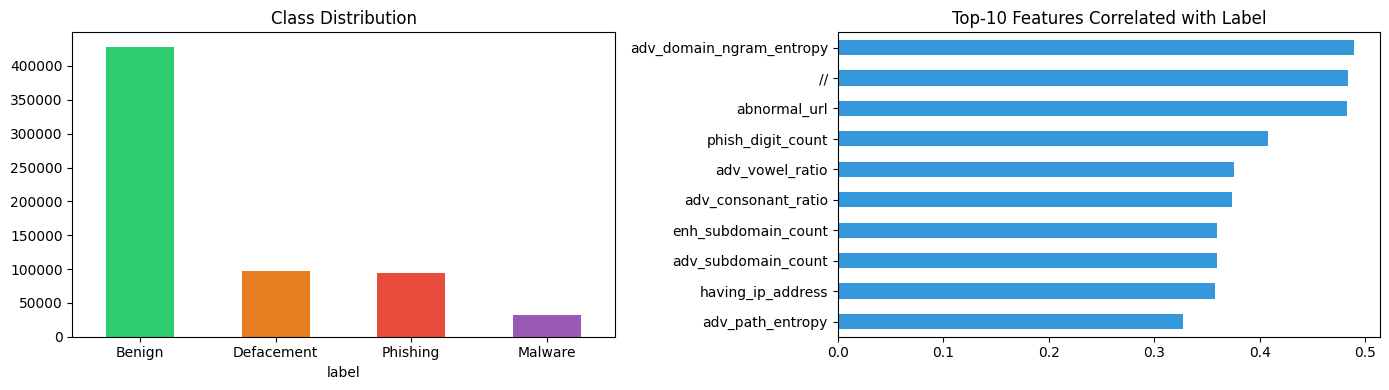

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
labels = ['Benign','Defacement','Phishing','Malware']

df['label'].value_counts().plot.bar(ax=axes[0], color=['#2ecc71','#e67e22','#e74c3c','#9b59b6'])
axes[0].set_xticklabels(labels, rotation=0);
axes[0].set_title('Class Distribution')

df.corr()['label'].drop('label').abs().sort_values(ascending=False).head(10).plot.barh(ax=axes[1], color='#3498db')
axes[1].set_title('Top-10 Features Correlated with Label'); axes[1].invert_yaxis()
plt.tight_layout();
plt.show()

## 6. Model Training & Baseline Results


In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.9568  Precision = 0.9566 Recall = 0.9568 F1=0.9567
KNN (k=5): Acc=0.9631  Precision = 0.9625 Recall = 0.9631 F1=0.9624
Logistic Reg: Acc=0.9010  Precision = 0.8979 Recall = 0.9010 F1=0.8933


## 7. Decision Tree — Depth Tuning


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8494     0.8211  0.8494    0.8169
5            0.8970     0.8980  0.8970    0.8876
10           0.9330     0.9333  0.9330    0.9296
15           0.9532     0.9528  0.9532    0.9516
20           0.9607     0.9601  0.9607    0.9596
None         0.9569     0.9566  0.9569    0.9568


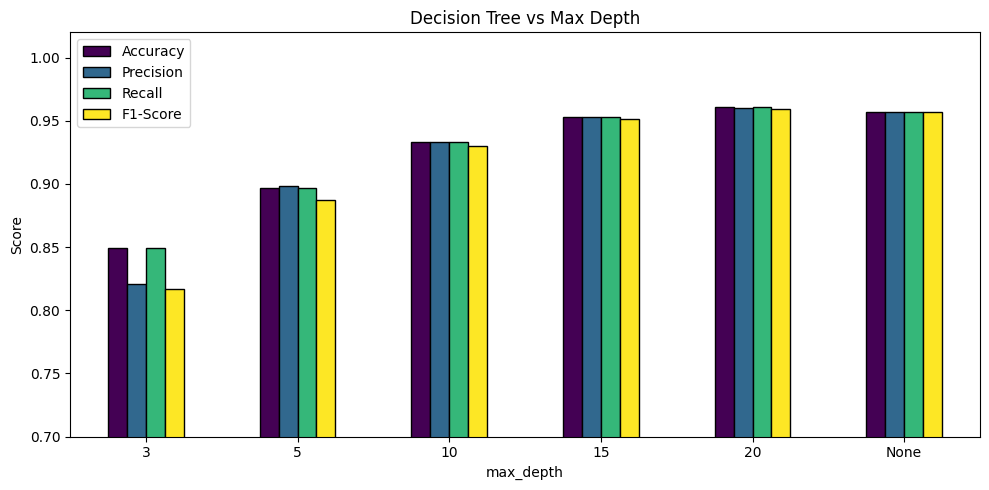

In [ ]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'), 'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 8. Classification Reports


In [ ]:
target_names = ['Benign', 'Defacement', 'Phishing', 'Malware']
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
              precision    recall  f1-score   support

      Benign     0.9735    0.9763    0.9749     85657
  Defacement     0.9771    0.9783    0.9777     19291
    Phishing     0.8622    0.8504    0.8563     18787
     Malware     0.9470    0.9450    0.9460      6504

    accuracy                         0.9568    130239
   macro avg     0.9399    0.9375    0.9387    130239
weighted avg     0.9566    0.9568    0.9567    130239


KNN (k=5)
              precision    recall  f1-score   support

      Benign     0.9699    0.9887    0.9792     85657
  Defacement     0.9653    0.9876    0.9763     19291
    Phishing     0.9248    0.8325    0.8762     18787
     Malware     0.9648    0.9311    0.9477      6504

    accuracy                         0.9631    130239
   macro avg     0.9562    0.9350    0.9449    130239
weighted avg     0.9625    0.9631    0.9624    130239


Logistic Reg
              precision    recall  f1-score   support

      Benign     0.9134    0.9797  

## 9. Confusion Matrices


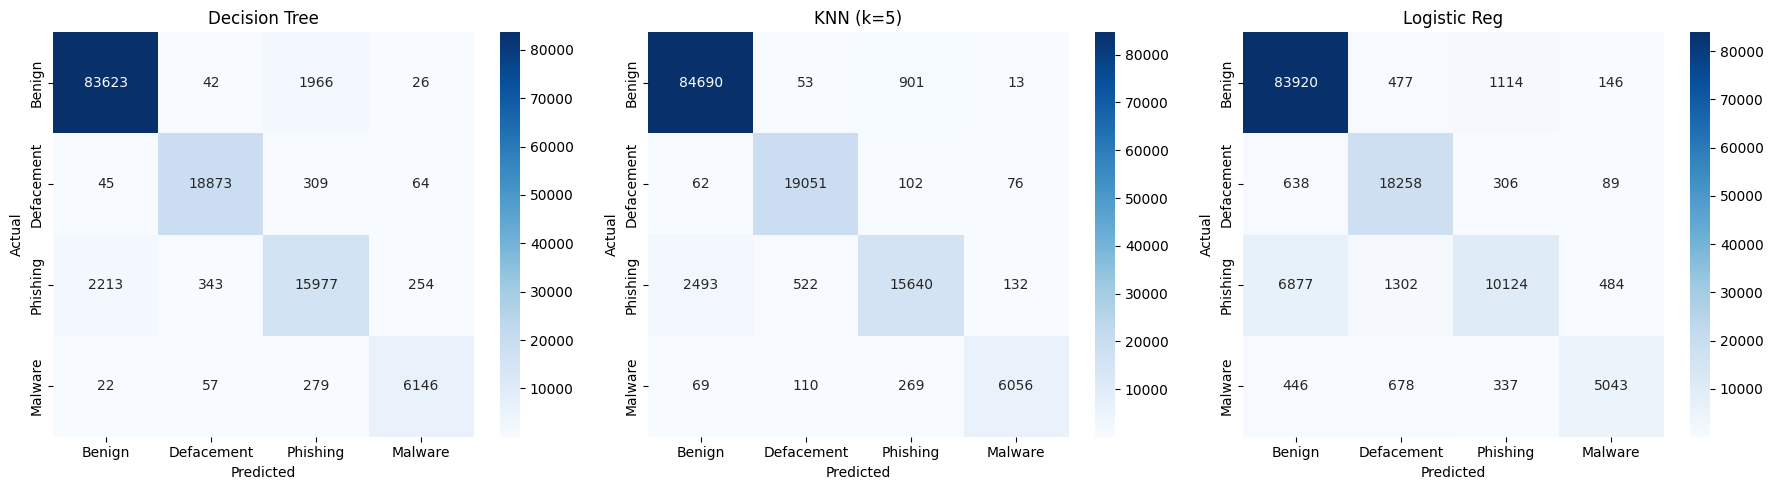

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 10. Model Comparison


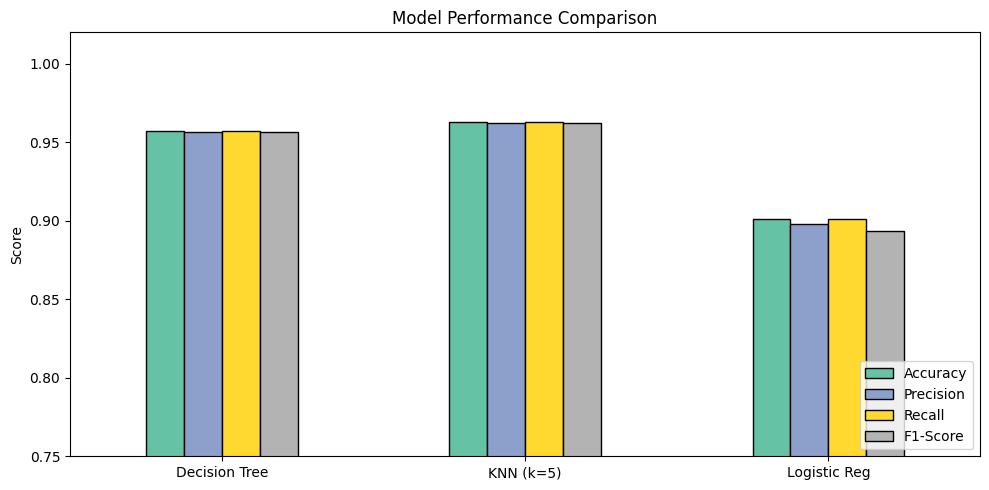


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.9568     0.9566  0.9568    0.9567
KNN (k=5)        0.9631     0.9625  0.9631    0.9624
Logistic Reg     0.9010     0.8979  0.9010    0.8933


In [ ]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df.round(4))

## 11. Assignment

**Dataset:** [Cybersecurity Intrusion Detection Dataset](https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset)

Upload the dataset to your Google Drive under `datasets/` and complete the following tasks using the **same workflow** as this notebook.

| Task | What to do |
|------|------------|
| **1. Load & Inspect** | Load CSV, print shape, missing values, and class distribution |
| **2. Preprocess** | Drop irrelevant columns, fill missing values with median, scale features, split 80/20 |
| **3. EDA** | Bar chart of class distribution + top-10 feature correlations |
| **4. Train Models** | Decision Tree, KNN (k=5), Logistic Regression — report Accuracy, Precision, Recall, F1 |
| **5. Depth Tuning** | Decision Tree with max_depth = [3, 5, 10, 15, 20, None] — table + bar chart |
| **6. Evaluate** | Classification reports + 1×3 confusion matrix grid + model comparison bar chart |

**Submit:** Single `.ipynb` with all cells executed and clean output.